# Generate Synthetic Customer Churn Data and Train a Baseline ML Model

This notebook creates a reproducible synthetic customer-churn dataset and trains a baseline Logistic Regression model.

## Target definition

- `churn = 1`: the customer cancelled the subscription.
- `churn = 0`: the customer remained.

## Important limitation

Synthetic data are useful for:

- testing data pipelines;
- practicing SQL and Python analysis;
- validating metrics;
- developing model-evaluation workflows;
- simulating errors and edge cases.

Synthetic data should **not** be used to make claims about real customers or real business behavior unless the generation process has been calibrated and validated against real data.


## 1. Import libraries

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 2. Define the random seed and dataset size

In [2]:
RANDOM_SEED = 42
N_CUSTOMERS = 5000

rng = np.random.default_rng(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)
print("Number of customers:", N_CUSTOMERS)


Random seed: 42
Number of customers: 5000


## 3. Create customer IDs

In [3]:
customer_id = [
    f"CUST_{number:06d}"
    for number in range(1, N_CUSTOMERS + 1)
]

customer_id[:10]


['CUST_000001',
 'CUST_000002',
 'CUST_000003',
 'CUST_000004',
 'CUST_000005',
 'CUST_000006',
 'CUST_000007',
 'CUST_000008',
 'CUST_000009',
 'CUST_000010']

## 4. Generate customer ages

In [4]:
age = rng.normal(
    loc=41,
    scale=13,
    size=N_CUSTOMERS,
)

age = np.round(age)
age = np.clip(age, 18, 80)
age = age.astype(int)

age[:10]


array([45, 27, 51, 53, 18, 24, 43, 37, 41, 30])

## 5. Generate customer regions

In [5]:
region_categories = [
    "North",
    "South",
    "East",
    "West",
    "Central",
]

region_probabilities = [
    0.17,
    0.20,
    0.24,
    0.23,
    0.16,
]

region = rng.choice(
    region_categories,
    size=N_CUSTOMERS,
    p=region_probabilities,
)

pd.Series(region).value_counts(normalize=True).round(3)


,proportion
East,0.240
West,0.234
South,0.198
North,0.172
Central,0.156


## 6. Generate subscription plans

In [6]:
plan_categories = [
    "Basic",
    "Standard",
    "Premium",
]

plan_probabilities = [
    0.45,
    0.38,
    0.17,
]

plan = rng.choice(
    plan_categories,
    size=N_CUSTOMERS,
    p=plan_probabilities,
)

pd.Series(plan).value_counts(normalize=True).round(3)


,proportion
Basic,0.447
Standard,0.386
Premium,0.167


## 7. Generate monthly fees

In [7]:
base_fee_by_plan = {
    "Basic": 29.90,
    "Standard": 59.90,
    "Premium": 99.90,
}

monthly_fee = np.array([
    base_fee_by_plan[current_plan]
    for current_plan in plan
])

monthly_fee_noise = rng.normal(
    loc=0,
    scale=5,
    size=N_CUSTOMERS,
)

monthly_fee = monthly_fee + monthly_fee_noise
monthly_fee = np.clip(monthly_fee, 12, 130)
monthly_fee = np.round(monthly_fee, 2)

monthly_fee[:10]


array([ 35.72,  31.38,  35.73,  22.51,  27.74,  33.46, 101.62,  25.59,
        34.57,  97.24])

## 8. Generate active months

In [8]:
months_active = rng.gamma(
    shape=2.2,
    scale=11,
    size=N_CUSTOMERS,
)

months_active = np.round(months_active)
months_active = np.clip(months_active, 1, 72)
months_active = months_active.astype(int)

months_active[:10]


array([12, 20, 10, 24, 12, 49, 26, 59, 38, 36])

## 9. Define the plan effect on usage

In [9]:
plan_usage_effect = np.select(
    [
        plan == "Basic",
        plan == "Standard",
        plan == "Premium",
    ],
    [
        0.85,
        1.00,
        1.18,
    ],
)

plan_usage_effect[:10]


array([0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 1.18, 0.85, 0.85, 1.18])

## 10. Generate monthly usage hours

In [10]:
usage_hours = rng.gamma(
    shape=3,
    scale=11,
    size=N_CUSTOMERS,
)

usage_hours = usage_hours * plan_usage_effect

tenure_usage_effect = np.minimum(
    months_active,
    24,
) * 0.15

usage_hours = usage_hours + tenure_usage_effect
usage_hours = np.clip(usage_hours, 0.5, 150)
usage_hours = np.round(usage_hours, 2)

usage_hours[:10]


array([53.67, 23.32,  7.28, 43.79, 27.24, 14.91, 24.29, 20.74, 25.7 ,
       41.03])

## 11. Generate support tickets

In [11]:
low_usage_effect = np.maximum(
    20 - usage_hours,
    0,
) / 18

premium_support_effect = (
    plan == "Premium"
).astype(int) * 0.15

support_ticket_rate = (
    0.7
    + low_usage_effect
    + premium_support_effect
)

support_tickets = rng.poisson(
    support_ticket_rate
)

support_tickets = np.clip(
    support_tickets,
    0,
    15,
)

support_tickets = support_tickets.astype(int)

support_tickets[:10]


array([1, 1, 2, 2, 2, 1, 0, 0, 1, 1])

## 12. Generate failed payments

In [12]:
failed_payment_rate = (
    0.12
    + 0.003 * monthly_fee
    + 0.035 * support_tickets
)

failed_payments = rng.poisson(
    failed_payment_rate
)

failed_payments = np.clip(
    failed_payments,
    0,
    6,
)

failed_payments = failed_payments.astype(int)

pd.Series(failed_payments).value_counts().sort_index()


,count
0,3696
1,1114
2,164
3,26


## 13. Define subscription-plan effects on churn

In [13]:
plan_churn_effect = np.select(
    [
        plan == "Basic",
        plan == "Standard",
        plan == "Premium",
    ],
    [
        0.22,
        0.00,
        -0.12,
    ],
)

plan_churn_effect[:10]


array([ 0.22,  0.22,  0.22,  0.22,  0.22,  0.22, -0.12,  0.22,  0.22,
       -0.12])

## 14. Define regional effects on churn

In [14]:
region_churn_effect = np.select(
    [
        region == "North",
        region == "South",
        region == "East",
        region == "West",
        region == "Central",
    ],
    [
        0.08,
        -0.05,
        0.03,
        0.10,
        -0.04,
    ],
)

region_churn_effect[:10]


array([-0.05,  0.03,  0.03,  0.03,  0.08,  0.03, -0.05, -0.04, -0.04,
       -0.05])

## 15. Generate customer-behavior noise

In [15]:
behavior_noise = rng.normal(
    loc=0,
    scale=0.35,
    size=N_CUSTOMERS,
)

behavior_noise[:10]

array([ 0.21962772,  0.39841104, -0.20513589,  0.12288833, -0.0438125 ,
        0.23864679, -0.15622845,  0.35488651, -0.05019043, -0.11097768])

## 16. Calculate churn log-odds

The synthetic target is generated from explicit relationships:

- more failed payments increase churn;
- more support tickets increase churn;
- longer tenure reduces churn;
- higher usage reduces churn;
- higher fees slightly increase churn;
- random noise prevents perfect predictability.


In [16]:
log_odds = (
    -1.45
    + 0.018 * (35 - age)
    + 0.014 * (monthly_fee - 55)
    - 0.027 * months_active
    - 0.022 * (usage_hours - 30)
    + 0.30 * support_tickets
    + 0.72 * failed_payments
    + plan_churn_effect
    + region_churn_effect
    + behavior_noise
)

log_odds[:10]

array([-1.33503228, -0.36130896, -1.13307589, -2.20735167, -0.9327325 ,
       -1.75593321, -1.84392845, -2.75213349, -1.62561043, -1.96427768])

## 17. Convert log-odds into churn probabilities

In [17]:
churn_probability = 1 / (
    1 + np.exp(-log_odds)
)

print("Minimum probability:", churn_probability.min())
print("Maximum probability:", churn_probability.max())

churn_probability[:10]


Minimum probability: 0.003943984802856178
Maximum probability: 0.8962931507484199


array([0.20832819, 0.41064274, 0.2435939 , 0.09909225, 0.28237068,
       0.14730041, 0.13658734, 0.05996627, 0.16443258, 0.12300485])

## 18. Generate the binary churn target

In [18]:
churn = rng.binomial(
    n=1,
    p=churn_probability,
)

churn = churn.astype(int)

pd.Series(churn).value_counts(normalize=True).round(4)

,proportion
0,0.8194
1,0.1806


## 19. Create the DataFrame

In [19]:
df = pd.DataFrame({
    "customer_id": customer_id,
    "age": age,
    "region": region,
    "plan": plan,
    "monthly_fee": monthly_fee,
    "months_active": months_active,
    "usage_hours": usage_hours,
    "support_tickets": support_tickets,
    "failed_payments": failed_payments,
    "churn": churn,
})

df.head()

,customer_id,age,region,plan,monthly_fee,months_active,usage_hours,support_tickets,failed_payments,churn
0,CUST_000001,45,South,Basic,35.72,12,53.67,1,1,1
1,CUST_000002,27,East,Basic,31.38,20,23.32,1,1,0
2,CUST_000003,51,East,Basic,35.73,10,7.28,2,0,0
3,CUST_000004,53,East,Basic,22.51,24,43.79,2,0,0
4,CUST_000005,18,North,Basic,27.74,12,27.24,2,0,0


## 20. Inspect the dataset dimensions and types

In [20]:
print("Dataset shape:", df.shape)
print()
df.info()

Dataset shape: (5000, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      5000 non-null   object 
 1   age              5000 non-null   int64  
 2   region           5000 non-null   object 
 3   plan             5000 non-null   object 
 4   monthly_fee      5000 non-null   float64
 5   months_active    5000 non-null   int64  
 6   usage_hours      5000 non-null   float64
 7   support_tickets  5000 non-null   int64  
 8   failed_payments  5000 non-null   int64  
 9   churn            5000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 390.8+ KB


## 21. Display summary statistics

In [21]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,5000,CUST_005000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,40.955,12.529356,18.0,32.0,41.0,49.0,80.0
region,5000,5,East,1199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan,5000,3,Basic,2235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_fee,5000.0,NaN,NaN,NaN,53.348488,25.468122,12.0,31.0475,54.57,64.0425,114.35
months_active,5000.0,NaN,NaN,NaN,24.0834,15.618298,1.0,12.0,21.0,32.0,72.0
usage_hours,5000.0,NaN,NaN,NaN,34.73684,19.6561,2.04,20.38,30.62,44.8925,141.29
support_tickets,5000.0,NaN,NaN,NaN,0.8094,0.916318,0.0,0.0,1.0,1.0,5.0
failed_payments,5000.0,NaN,NaN,NaN,0.304,0.555379,0.0,0.0,0.0,1.0,3.0
churn,5000.0,NaN,NaN,NaN,0.1806,0.384725,0.0,0.0,0.0,0.0,1.0


## 22. Check missing values and duplicates

In [22]:
quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
    "data_type": df.dtypes.astype(str),
})

print("Duplicated complete rows:", df.duplicated().sum())
print("Duplicated customer IDs:", df["customer_id"].duplicated().sum())

quality_summary


Duplicated complete rows: 0
Duplicated customer IDs: 0


,missing_values,unique_values,data_type
customer_id,0,5000,object
age,0,63,int64
region,0,5,object
plan,0,3,object
monthly_fee,0,3212,float64
months_active,0,72,int64
usage_hours,0,3427,float64
support_tickets,0,6,int64
failed_payments,0,4,int64
churn,0,2,int64


## 23. Validate the target and allowed ranges

In [23]:
assert df.shape == (N_CUSTOMERS, 10)
assert df["customer_id"].is_unique
assert df.isna().sum().sum() == 0
assert set(df["churn"].unique()).issubset({0, 1})
assert df["age"].between(18, 80).all()
assert df["monthly_fee"].between(12, 130).all()
assert df["months_active"].between(1, 72).all()
assert df["usage_hours"].between(0.5, 150).all()
assert df["support_tickets"].between(0, 15).all()
assert df["failed_payments"].between(0, 6).all()

print("All initial dataset validation checks passed.")


All initial dataset validation checks passed.


## 24. Examine the churn distribution

In [24]:
churn_summary = (
    df["churn"]
    .value_counts()
    .rename_axis("churn")
    .reset_index(name="customer_count")
)

churn_summary["percentage"] = (
    churn_summary["customer_count"]
    / len(df)
    * 100
).round(2)

churn_summary


,churn,customer_count,percentage
0,0,4097,81.94
1,1,903,18.06


## 25. Plot the churn distribution

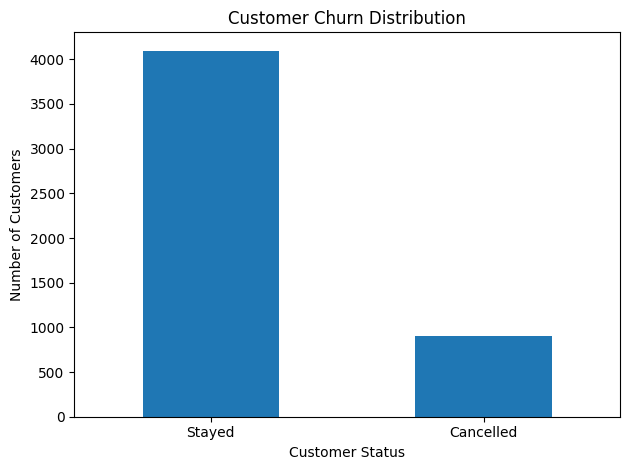

In [25]:
churn_labels = df["churn"].map({
    0: "Stayed",
    1: "Cancelled",
})

churn_labels.value_counts().plot(
    kind="bar",
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 26. Compare numerical variables by churn status

In [26]:
numerical_columns = [
    "age",
    "monthly_fee",
    "months_active",
    "usage_hours",
    "support_tickets",
    "failed_payments",
]

df.groupby("churn")[numerical_columns].mean().round(2)


,age,monthly_fee,months_active,usage_hours,support_tickets,failed_payments
churn,,,,,,
0,41.40,52.35,24.96,36.01,0.75,0.26
1,38.91,57.89,20.11,28.97,1.06,0.52


## 27. Calculate churn rates by plan, region, and failed payments

In [27]:
churn_by_plan = (
    df.groupby("plan")["churn"]
    .agg(customer_count="count", churn_rate="mean")
)

churn_by_plan["churn_rate"] = (
    churn_by_plan["churn_rate"] * 100
).round(2)

churn_by_region = (
    df.groupby("region")["churn"]
    .agg(customer_count="count", churn_rate="mean")
)

churn_by_region["churn_rate"] = (
    churn_by_region["churn_rate"] * 100
).round(2)

churn_by_failed_payments = (
    df.groupby("failed_payments")["churn"]
    .agg(customer_count="count", churn_rate="mean")
)

churn_by_failed_payments["churn_rate"] = (
    churn_by_failed_payments["churn_rate"] * 100
).round(2)

print("Churn by plan")
display(churn_by_plan)

print("Churn by region")
display(churn_by_region)

print("Churn by failed payments")
display(churn_by_failed_payments)


Churn by plan


,customer_count,churn_rate
plan,,
Basic,2235,15.57
Premium,834,24.46
Standard,1931,18.18


Churn by region


,customer_count,churn_rate
region,,
Central,781,18.57
East,1199,17.93
North,860,18.37
South,990,17.47
West,1170,18.12


Churn by failed payments


,customer_count,churn_rate
failed_payments,,
0,3696,14.34
1,1114,25.76
2,164,45.73
3,26,42.31


## 28. Save the synthetic dataset

In [28]:
DATA_FILE = Path("synthetic_customer_churn.csv")

df.to_csv(
    DATA_FILE,
    index=False,
)

print("Dataset saved as:", DATA_FILE)


Dataset saved as: synthetic_customer_churn.csv


## 29. Reload and validate the saved CSV

In [29]:
df_loaded = pd.read_csv(
    DATA_FILE
)

assert df_loaded.shape == (N_CUSTOMERS, 10)
assert df_loaded["customer_id"].is_unique
assert df_loaded.isna().sum().sum() == 0
assert set(df_loaded["churn"].unique()).issubset({0, 1})

print("The saved CSV was reloaded successfully.")
df_loaded.head()


The saved CSV was reloaded successfully.


,customer_id,age,region,plan,monthly_fee,months_active,usage_hours,support_tickets,failed_payments,churn
0,CUST_000001,45,South,Basic,35.72,12,53.67,1,1,1
1,CUST_000002,27,East,Basic,31.38,20,23.32,1,1,0
2,CUST_000003,51,East,Basic,35.73,10,7.28,2,0,0
3,CUST_000004,53,East,Basic,22.51,24,43.79,2,0,0
4,CUST_000005,18,North,Basic,27.74,12,27.24,2,0,0


# Baseline Machine-Learning Model

The goal of this section is to build a simple, reproducible baseline model.

The model is intentionally simple because the portfolio project should focus on:

- data validation;
- metric validation;
- model-output analysis;
- failure-mode analysis;
- reproducibility.


## 30. Separate features and target

In [30]:
X = df_loaded.drop(
    columns=[
        "customer_id",
        "churn",
    ]
)

y = df_loaded["churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()


Feature matrix shape: (5000, 8)
Target shape: (5000,)


,age,region,plan,monthly_fee,months_active,usage_hours,support_tickets,failed_payments
0,45,South,Basic,35.72,12,53.67,1,1
1,27,East,Basic,31.38,20,23.32,1,1
2,51,East,Basic,35.73,10,7.28,2,0
3,53,East,Basic,22.51,24,43.79,2,0
4,18,North,Basic,27.74,12,27.24,2,0


## 31. Create training and test sets

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training churn rate:", round(y_train.mean(), 4))
print("Test churn rate:", round(y_test.mean(), 4))


Training rows: 4000
Test rows: 1000
Training churn rate: 0.1805
Test churn rate: 0.181


## 32. Define numerical and categorical columns

In [32]:
numerical_features = [
    "age",
    "monthly_fee",
    "months_active",
    "usage_hours",
    "support_tickets",
    "failed_payments",
]

categorical_features = [
    "region",
    "plan",
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['age', 'monthly_fee', 'months_active', 'usage_hours', 'support_tickets', 'failed_payments']
Categorical features: ['region', 'plan']


## 33. Create the preprocessing pipeline

In [33]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)


## 34. Create the Logistic Regression model pipeline

In [34]:
model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

model_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'monthly_fee',
                                                   'months_active',
                                                   'usage_hours',
                                                   'support_tickets',
                                                   'failed_payments']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['region', 'plan'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 35. Train the model

In [35]:
model_pipeline.fit(
    X_train,
    y_train,
)

print("Model training completed.")


Model training completed.


## 36. Generate class predictions and probabilities

In [36]:
y_pred = model_pipeline.predict(
    X_test
)

y_probability = model_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_probability[:10])


Predicted labels: [0 0 0 0 0 1 1 0 0 0]
Predicted probabilities: [0.27849274 0.13824222 0.32271565 0.37372263 0.35844252 0.61667489
 0.50147385 0.3728679  0.43609018 0.40777407]


## 37. Calculate evaluation metrics

In [37]:
metrics = {
    "accuracy": accuracy_score(
        y_test,
        y_pred,
    ),
    "precision": precision_score(
        y_test,
        y_pred,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        y_pred,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        y_pred,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_probability,
    ),
    "pr_auc": average_precision_score(
        y_test,
        y_probability,
    ),
    "log_loss": log_loss(
        y_test,
        y_probability,
    ),
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=[
        "metric",
        "value",
    ],
)

metrics_df["value"] = metrics_df["value"].round(4)

metrics_df


,metric,value
0,accuracy,0.6650
1,precision,0.3005
2,recall,0.6409
3,f1_score,0.4092
4,roc_auc,0.7149
5,pr_auc,0.4088
6,log_loss,0.6198


## 38. Display the classification report

In [38]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stayed",
            "Cancelled",
        ],
        zero_division=0,
    )
)


              precision    recall  f1-score   support

      Stayed       0.89      0.67      0.77       819
   Cancelled       0.30      0.64      0.41       181

    accuracy                           0.67      1000
   macro avg       0.60      0.66      0.59      1000
weighted avg       0.79      0.67      0.70      1000



## 39. Display the confusion matrix

In [39]:
confusion = confusion_matrix(
    y_test,
    y_pred,
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "Actual Stayed",
        "Actual Cancelled",
    ],
    columns=[
        "Predicted Stayed",
        "Predicted Cancelled",
    ],
)

confusion_df


,Predicted Stayed,Predicted Cancelled
Actual Stayed,549,270
Actual Cancelled,65,116


## 40. Calculate specificity manually

In [40]:
true_negative = confusion[0, 0]
false_positive = confusion[0, 1]
false_negative = confusion[1, 0]
true_positive = confusion[1, 1]

specificity = (
    true_negative
    / (true_negative + false_positive)
)

print("True negatives:", true_negative)
print("False positives:", false_positive)
print("False negatives:", false_negative)
print("True positives:", true_positive)
print("Specificity:", round(specificity, 4))


True negatives: 549
False positives: 270
False negatives: 65
True positives: 116
Specificity: 0.6703


## 41. Create a prediction-results table

In [41]:
test_customer_ids = df_loaded.loc[
    X_test.index,
    "customer_id",
]

prediction_results = pd.DataFrame({
    "customer_id": test_customer_ids.values,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "churn_probability": y_probability,
    "model_name": "logistic_regression",
    "model_version": "v1",
    "experiment_id": "EXP_001",
})

prediction_results["error_type"] = np.select(
    [
        (
            prediction_results["y_true"] == 0
        )
        & (
            prediction_results["y_pred"] == 1
        ),
        (
            prediction_results["y_true"] == 1
        )
        & (
            prediction_results["y_pred"] == 0
        ),
    ],
    [
        "false_positive",
        "false_negative",
    ],
    default="correct",
)

prediction_results.head()


,customer_id,y_true,y_pred,churn_probability,model_name,model_version,experiment_id,error_type
0,CUST_001104,0,0,0.278493,logistic_regression,v1,EXP_001,correct
1,CUST_000538,0,0,0.138242,logistic_regression,v1,EXP_001,correct
2,CUST_003397,0,0,0.322716,logistic_regression,v1,EXP_001,correct
3,CUST_001694,0,0,0.373723,logistic_regression,v1,EXP_001,correct
4,CUST_004514,0,0,0.358443,logistic_regression,v1,EXP_001,correct


## 42. Validate model outputs

In [42]:
assert len(prediction_results) == len(X_test)
assert prediction_results["customer_id"].is_unique
assert prediction_results["y_true"].isin([0, 1]).all()
assert prediction_results["y_pred"].isin([0, 1]).all()
assert prediction_results["churn_probability"].between(0, 1).all()
assert prediction_results.isna().sum().sum() == 0

print("All prediction-output validation checks passed.")


All prediction-output validation checks passed.


## 43. Analyze prediction errors

In [43]:
error_summary = (
    prediction_results["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

error_summary


,error_type,count
0,correct,665
1,false_positive,270
2,false_negative,65


## 44. Examine the most confident incorrect predictions

In [44]:
incorrect_predictions = prediction_results.loc[
    prediction_results["error_type"] != "correct"
].copy()

incorrect_predictions["confidence"] = np.where(
    incorrect_predictions["y_pred"] == 1,
    incorrect_predictions["churn_probability"],
    1 - incorrect_predictions["churn_probability"],
)

incorrect_predictions.sort_values(
    "confidence",
    ascending=False,
).head(20)


,customer_id,y_true,y_pred,churn_probability,model_name,model_version,experiment_id,error_type,confidence
491,CUST_003528,0,1,0.923950,logistic_regression,v1,EXP_001,false_positive,0.923950
789,CUST_002575,0,1,0.889269,logistic_regression,v1,EXP_001,false_positive,0.889269
356,CUST_002269,0,1,0.864985,logistic_regression,v1,EXP_001,false_positive,0.864985
506,CUST_001576,0,1,0.857668,logistic_regression,v1,EXP_001,false_positive,0.857668
922,CUST_003193,0,1,0.841566,logistic_regression,v1,EXP_001,false_positive,0.841566
209,CUST_003160,0,1,0.837169,logistic_regression,v1,EXP_001,false_positive,0.837169
915,CUST_000698,0,1,0.833723,logistic_regression,v1,EXP_001,false_positive,0.833723
354,CUST_001377,0,1,0.829508,logistic_regression,v1,EXP_001,false_positive,0.829508
851,CUST_004661,0,1,0.825022,logistic_regression,v1,EXP_001,false_positive,0.825022
406,CUST_000312,0,1,0.824823,logistic_regression,v1,EXP_001,false_positive,0.824823


## 45. Evaluate the model by subscription plan

In [45]:
test_context = df_loaded.loc[
    X_test.index,
    [
        "customer_id",
        "plan",
        "region",
    ],
].copy()

subgroup_results = prediction_results.merge(
    test_context,
    on="customer_id",
    how="left",
)

plan_metrics = (
    subgroup_results
    .groupby("plan")
    .apply(
        lambda group: pd.Series({
            "sample_count": len(group),
            "accuracy": accuracy_score(
                group["y_true"],
                group["y_pred"],
            ),
            "precision": precision_score(
                group["y_true"],
                group["y_pred"],
                zero_division=0,
            ),
            "recall": recall_score(
                group["y_true"],
                group["y_pred"],
                zero_division=0,
            ),
            "f1_score": f1_score(
                group["y_true"],
                group["y_pred"],
                zero_division=0,
            ),
        }),
        include_groups=False,
    )
    .round(4)
)

plan_metrics


,sample_count,accuracy,precision,recall,f1_score
plan,,,,,
Basic,423.0,0.6809,0.1970,0.4727,0.2781
Premium,172.0,0.5465,0.3398,0.7778,0.4730
Standard,405.0,0.6988,0.3642,0.6790,0.4741


## 46. Save predictions, metrics, and the trained model

In [46]:
PREDICTIONS_FILE = Path(
    "logistic_regression_predictions.csv"
)

METRICS_FILE = Path(
    "logistic_regression_metrics.json"
)

MODEL_FILE = Path(
    "logistic_regression_pipeline.joblib"
)

prediction_results.to_csv(
    PREDICTIONS_FILE,
    index=False,
)

with METRICS_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            key: float(value)
            for key, value in metrics.items()
        },
        file,
        indent=2,
    )

joblib.dump(
    model_pipeline,
    MODEL_FILE,
)

print("Saved dataset:", DATA_FILE)
print("Saved predictions:", PREDICTIONS_FILE)
print("Saved metrics:", METRICS_FILE)
print("Saved model:", MODEL_FILE)


Saved dataset: synthetic_customer_churn.csv
Saved predictions: logistic_regression_predictions.csv
Saved metrics: logistic_regression_metrics.json
Saved model: logistic_regression_pipeline.joblib


## 47. Optional: download the generated files in Google Colab

In [47]:
try:
    from google.colab import files

    files.download(str(DATA_FILE))
    files.download(str(PREDICTIONS_FILE))
    files.download(str(METRICS_FILE))
    files.download(str(MODEL_FILE))
except ImportError:
    print(
        "This cell is intended for Google Colab. "
        "The files are already available in the current working directory."
    )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
reported_metrics_df = pd.DataFrame([
    {
        "experiment_id": "EXP_001",
        "metric_name": metric_name,
        "metric_value": float(metric_value)
    }
    for metric_name, metric_value in metrics.items()
])

reported_metrics_df

,experiment_id,metric_name,metric_value
0,EXP_001,accuracy,0.665000
1,EXP_001,precision,0.300518
2,EXP_001,recall,0.640884
3,EXP_001,f1_score,0.409171
4,EXP_001,roc_auc,0.714859
5,EXP_001,pr_auc,0.408750
6,EXP_001,log_loss,0.619833


In [49]:
reported_metrics_df.to_csv(
    "reported_metrics.csv",
    index=False
)

In [50]:
from google.colab import files

files.download("reported_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Next steps

After completing this notebook, the recommended next stage is to build an evaluation benchmark that:

1. stores experiments and predictions in SQL;
2. independently recomputes reported metrics;
3. detects duplicated or missing predictions;
4. tests different decision thresholds;
5. compares multiple models;
6. analyzes false positives and false negatives;
7. simulates invalid experiment outputs and failure logs.
